# Introduction
<font size=4>

- The VIX index is not directly tradable -- VIX futures are the primary tradable instrument and can be used to hedge the short-volatility exposure embedded in carry strategies.
- Backtesting a futures trading strategy requires a rolling methodology that sells expiring contracts and buys new longer dated contracts.
- This notebook builds a portfolio that behaves like a VIX future with a constant 30 days to expiry.
- It holds weights $w_{\mathrm{front}}$ and $w_{\mathrm{back}}$ (with $w_{\mathrm{front}} + w_{\mathrm{back}} = 1$) such that the weighted time to expiry (TTE) is 30 days:

$$
w_{\mathrm{front}}\,T_{\mathrm{front}} + w_{\mathrm{back}}\,T_{\mathrm{back}} = 30\ \text{days}
$$
- By fixing the TTE, the strategy tracks the 30-day point on the term structure, making its VIX sensitivity and roll characteristics stationary through time.
- The data for this project was sourced from OptionMetrics' daily forward pricing table.
- Data issues are handled in this notebook using SQL, and the portfolio is calculated using my custom `derivatives_rebalancer` Python library.
- Strategy performance: 

<!-- <img src="./30%20day%20VIX%20futures%20performance.jpg" alt="strategy performance" width="800"> -->



In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect
from derivatives_rebalancer.constant_tte_future import ConstantTTEFuture
import pandas_market_calendars as mcal
import mpl_defaults
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data into Clickhouse view

In [25]:
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='default',
    password='',
)

client.command("CREATE DATABASE IF NOT EXISTS constant_tte_research")

# secid = 117801 is VIX futures
client.command("""
    CREATE OR REPLACE VIEW constant_tte_research.vix_forward_prices AS
    SELECT
        forward_prices.*,
        expiry_labels.expiry_indicator
    FROM option_metrics.forward_price AS forward_prices
    LEFT JOIN (
        SELECT DISTINCT
            exdate AS expiration,
            expiry_indicator
        FROM option_metrics.option_pricing
        WHERE secid = 117801
          AND am_settlement = 1
    ) AS expiry_labels USING (expiration)
    WHERE forward_prices.secid = 117801
      AND forward_prices.AMSettlement = 1
    ORDER BY expiration, date
""")


# Expiry series exploration

<font size=4>

confirmed expiry_indicator != 'w' are monthly contracts

In [26]:
expiries = client.query_df("""
    SELECT DISTINCT
        exdate AS expiration,
        expiry_indicator
    FROM option_metrics.option_pricing
    WHERE secid = 117801
    ORDER BY exdate, expiry_indicator
""")
expiries['expiry_series'] = expiries['expiry_indicator'].map({'': 'monthly', 'w': 'weekly'})
# expiries['expiration'] = pd.to_datetime(expiries['expiration'])

def get_third_friday(year, month):
    """Third Friday of a given month."""
    first = pd.Timestamp(year, month, 1)
    days_to_friday = (4 - first.dayofweek) % 7
    return first + pd.Timedelta(days=days_to_friday + 14)

def monthly_vix_settlement(year, month):
    """Wednesday 30 days before the third Friday of the following month."""
    if month == 12:
        next_year, next_month = year + 1, 1
    else:
        next_year, next_month = year, month + 1
    return get_third_friday(next_year, next_month) - pd.Timedelta(days=30)

def is_monthly_expiry(expiry, monthly_settlements, tol_days=1):
    """True if expiry is within tol_days of a standard monthly settlement (handles holiday shifts)."""
    return any(abs((expiry - settlement).days) <= tol_days for settlement in monthly_settlements)

years = range(
    expiries['expiration'].min().year - 1,
    expiries['expiration'].max().year + 2,
)
monthly_expiry_rule = pd.DatetimeIndex([
    monthly_vix_settlement(year, month)
    for year in years
    for month in range(1, 13)
])


monthly_expiries = expiries.loc[
    expiries['expiry_series'].eq('monthly'),
    ['expiration', 'expiry_indicator', 'expiry_series'],
].copy()
monthly_expiries['matches_monthly_expiry_rule'] = monthly_expiries['expiration'].map(
    lambda expiration: is_monthly_expiry(
        expiration,
        monthly_expiry_rule,
        tol_days=1,
    )
)

monthly_expiry_rule_exceptions = monthly_expiries.loc[
    ~monthly_expiries['expiration'].isin(monthly_expiry_rule)
]
monthly_expiry_rule_mismatches = monthly_expiries.loc[
    ~monthly_expiries['matches_monthly_expiry_rule']
]

# display(monthly_expiry_rule_exceptions)
# display(monthly_expiry_rule_mismatches)

assert monthly_expiry_rule_mismatches.empty, (
    'Some OptionMetrics monthly expiries do not match the monthly expiry rule '
    'within the one-day holiday tolerance.'
)

# Missing Forward Prices

<font size=5>

- There are zero prices and missing prices in the dataset.
- We can fill in the missing prices with the implied at the money forward.

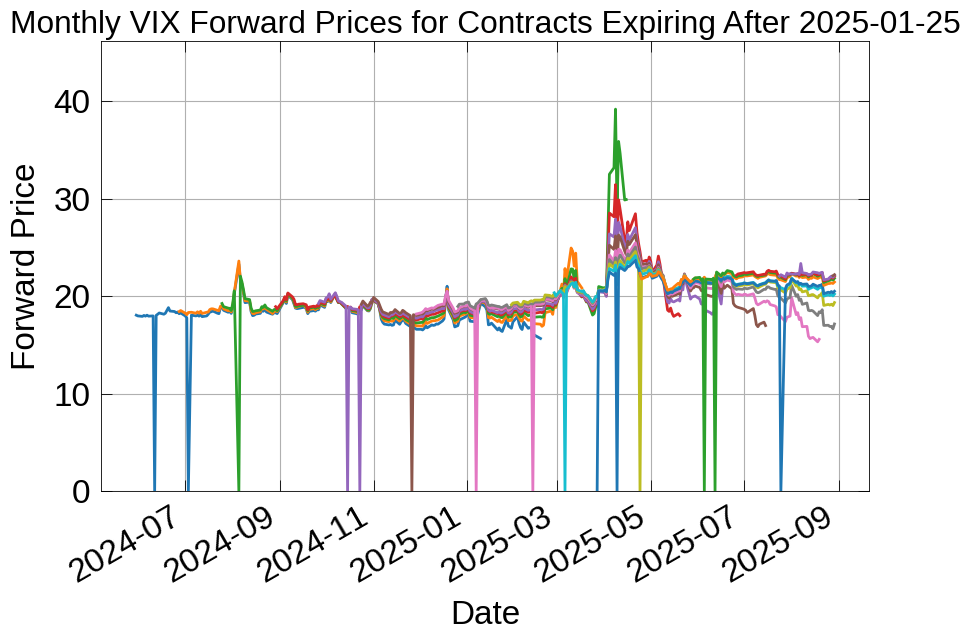

In [27]:
prices_exp2025 = client.query_df("""
    SELECT *
    FROM constant_tte_research.vix_forward_prices
    WHERE expiry_indicator = ''
      AND expiration >= '2025-01-25'
    ORDER BY date, expiration
""")



prices_exp2025['filtered_forward_price'] = prices_exp2025['ForwardPrice'].where(
    prices_exp2025['ForwardPrice'].gt(1.0)
)

fig, ax = plt.subplots(figsize=(12, 6))

for _, contract_prices in prices_exp2025.groupby('expiration', sort=True):
    ax.plot(
        contract_prices['date'],
        contract_prices['ForwardPrice'],linestyle='-')


ax.set_title('Monthly VIX Forward Prices for Contracts Expiring After 2025-01-25')
ax.set_xlabel('Date')
ax.set_ylabel('Forward Price')
ax.set_ylim(0, ax.get_ylim()[1])
ax.grid()
fig.autofmt_xdate()

## Imply missing forward price from options pricing

In [28]:
# create ATM implied forwards
client.command("""
    CREATE OR REPLACE VIEW constant_tte_research.atm_implied_forwards AS
    WITH
        deduped_options AS (
            SELECT DISTINCT
                options.optionid,
                options.date,
                options.exdate,
                options.cp_flag,
                options.strike_price,
                options.best_bid,
                options.best_offer
            FROM option_metrics.option_pricing AS options
            WHERE options.secid = 117801
              AND options.am_settlement = 1
        ),
        call_put_pairs AS (
            SELECT
                date,
                exdate,
                strike_price,
                anyIf(best_bid, cp_flag = 'C') AS call_bid,
                anyIf(best_offer, cp_flag = 'C') AS call_offer,
                anyIf(best_bid, cp_flag = 'P') AS put_bid,
                anyIf(best_offer, cp_flag = 'P') AS put_offer
            FROM deduped_options
            GROUP BY
                date,
                exdate,
                strike_price
            HAVING countIf(cp_flag = 'C') = 1
               AND countIf(cp_flag = 'P') = 1
        ),
        parity_by_strike AS (
            SELECT
                date,
                exdate,
                strike_price,
                strike_price / 1000.0
                    + call_bid
                    - put_offer AS forward_bid,
                strike_price / 1000.0
                    + call_offer
                    - put_bid AS forward_offer,
                strike_price / 1000.0
                    + ((call_bid + call_offer) - (put_bid + put_offer)) / 2.0 AS forward_mid,
                abs(((call_bid + call_offer) - (put_bid + put_offer)) / 2.0) AS strike_distance
            FROM call_put_pairs
            WHERE call_bid IS NOT NULL
              AND call_offer IS NOT NULL
              AND put_bid IS NOT NULL
              AND put_offer IS NOT NULL
        )
        
    SELECT
        date,
        exdate AS expiration,
        argMin(
            forward_mid,
            tuple(strike_distance, strike_price)
        ) AS atm_implied_forward_price
    FROM parity_by_strike
    GROUP BY (date, exdate)
    ORDER BY (date, exdate)
""")


# combine original and ATM-implied forward prices
client.command("""
    CREATE OR REPLACE VIEW constant_tte_research.vix_forward_prices_imputed AS
    SELECT
        forward_prices.*,
        implied.atm_implied_forward_price,
        if(
            ifNull(forward_prices.ForwardPrice > 1, false),
            forward_prices.ForwardPrice,
            implied.atm_implied_forward_price
        ) AS filled_forward_price,
        (
            NOT ifNull(forward_prices.ForwardPrice > 1, false)
            AND implied.atm_implied_forward_price IS NOT NULL
        ) AS is_imputed,
        (
            NOT ifNull(forward_prices.ForwardPrice > 1, false)
            AND implied.atm_implied_forward_price IS NULL
        ) AS imputation_failed
    FROM constant_tte_research.vix_forward_prices AS forward_prices
    LEFT JOIN constant_tte_research.atm_implied_forwards AS implied
        USING (date, expiration)
    ORDER BY
        expiration,
        date
""")


# Market calendar alignment

In [29]:
sched = mcal.get_calendar('CFE').schedule(start_date='2003-01-01', end_date='2027-12-31')
sessions = pd.DatetimeIndex(sched.index).normalize()
cal_df = pd.DataFrame({
    'exchange': 'CFE',
    'session_date': sessions.date,           # -> Date32
    'session_index': range(len(sessions)),   # dense 0..N-1, the key trick
})

client.command("""
    CREATE TABLE IF NOT EXISTS constant_tte_research.trading_calendar (
        exchange      LowCardinality(String),
        session_date  Date32,
        session_index UInt32
    ) ENGINE = MergeTree ORDER BY (exchange, session_date)
""")
# Idempotent load: MergeTree never dedupes, so re-running a plain insert_df would
# append a second copy. Only insert this exchange's calendar if it isn't already there.
existing = client.query(
    "SELECT count() FROM constant_tte_research.trading_calendar WHERE exchange = 'CFE'"
).result_rows[0][0]

if existing == 0:
    client.insert_df('constant_tte_research.trading_calendar', cal_df)
    print(f"Inserted {len(cal_df)} CFE sessions.")
elif existing == len(cal_df):
    print(f"CFE calendar already loaded ({existing} rows); skipping insert.")
else:
    print(f"WARNING: CFE has {existing} rows, expected {len(cal_df)}; not inserting "
          f"to avoid duplicates. TRUNCATE TABLE constant_tte_research.trading_calendar to reload.")

client.command(
    """CREATE OR REPLACE VIEW constant_tte_research.vix_forwards_cal_reindex AS
    SELECT
        fp.*,
        cal_e.session_index - cal_d.session_index AS trading_days_to_expiry
    FROM constant_tte_research.vix_forward_prices_imputed AS fp
    LEFT JOIN constant_tte_research.trading_calendar AS cal_d
        ON cal_d.exchange = 'CFE' AND cal_d.session_date = fp.date
    LEFT JOIN constant_tte_research.trading_calendar AS cal_e
        ON cal_e.exchange = 'CFE' AND cal_e.session_date = fp.expiration"""
)

CFE calendar already loaded (6289 rows); skipping insert.


In [30]:
# Load the equity reference for the run-up / drawdown analysis.
# We DO have the SPX index spot in OptionMetrics (security_prices, secid 108105),
# so use the index directly. Swap SPX_SECID -> 109820 to use the SPY ETF instead.
SPX_SECID = 108105

spx = client.query_df(f"""
    SELECT
        date,
        close  AS spx_close,
        return AS spx_return
    FROM option_metrics.security_prices
    WHERE secid = {SPX_SECID}
      AND date >= '2007-01-01'      -- matches the backtest start in the vix_futures cell
    ORDER BY date
""")
spx['date'] = pd.to_datetime(spx['date'])
spx = spx.set_index('date').sort_index()
spx.tail()

,spx_close,spx_return
date,,
2025-08-25,6439.32,-0.004266
2025-08-26,6465.94,0.004134
2025-08-27,6481.40,0.002391
2025-08-28,6501.86,0.003157
2025-08-29,6460.26,-0.006398


# 30 day constant TTE future

In [31]:
vix_futures = client.query_df("""
    SELECT
        expiration AS security,
        date,
        expiration AS expiry,
        filled_forward_price AS futures_price,
        trading_days_to_expiry
    FROM constant_tte_research.vix_forwards_cal_reindex
    WHERE expiry_indicator = ''
      AND expiration > date
      AND filled_forward_price IS NOT NULL
      AND date >= '2007-01-01'
    ORDER BY
        security,
        date
""")

vix_futures['security'] = pd.to_datetime(vix_futures['security'])
vix_futures['date'] = pd.to_datetime(vix_futures['date'])
vix_futures['expiry'] = pd.to_datetime(vix_futures['expiry'])
vix_futures = (
    vix_futures
    .set_index(['security', 'date'])
    .sort_index()
)

constant_tte_30d = ConstantTTEFuture(T_expiry=30, min_tte=2)
vix_30d = constant_tte_30d.create_synthetic_future(
    vix_futures,
    name_map={'sessions_col': 'trading_days_to_expiry'}
)

vix_30d['unit_contract_cumpnl'].isna().value_counts()

vix_30d['unit_contract_runup'] = vix_30d['unit_contract_cumpnl'] - vix_30d['unit_contract_cumpnl'].expanding().min()


Creating synthetic future with characteristic time to expiry of ~ (30 days)


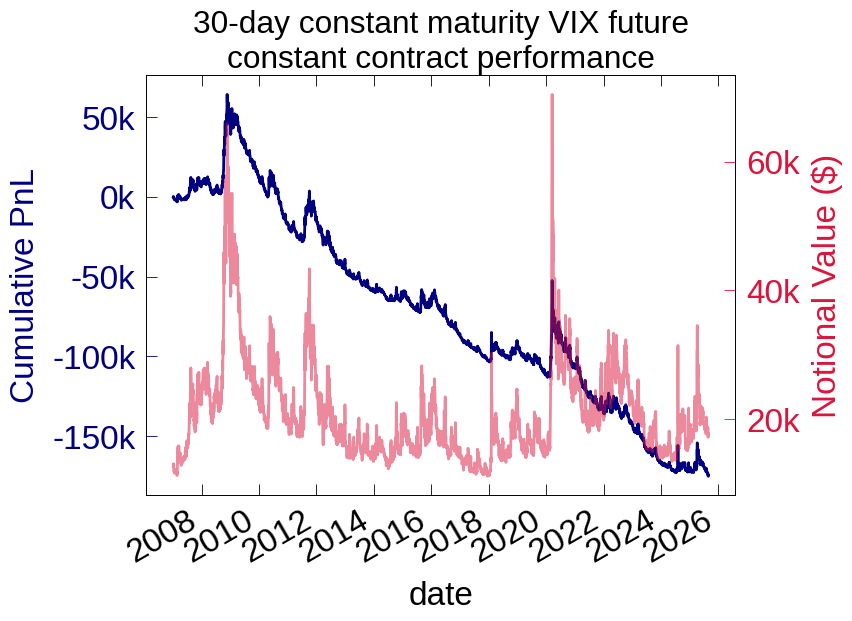

In [32]:
VIX_MULTIPLER = 1e3
CONTRACT_NUM = 1
fig, axes = plt.subplots(1, 1, figsize=(9.2, 5.6 ))
(VIX_MULTIPLER * CONTRACT_NUM * vix_30d['unit_contract_cumpnl']).plot(
    ax=axes, title='30-day constant maturity VIX future\nconstant contract performance', color='navy')

axes_twin = axes.twinx()
(VIX_MULTIPLER * CONTRACT_NUM * vix_30d['unit_contract_notional']).plot(ax=axes_twin, color='crimson', alpha=0.5)

for ax in [axes, axes_twin]:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k')
    )
axes.set_ylabel('Cumulative PnL', color='navy')
axes.tick_params(axis='y', colors='navy')

axes_twin.set_ylabel('Notional Value ($)', color='crimson')
axes_twin.tick_params(axis='y', colors='crimson')
# fig.savefig('30 day VIX futures performance.jpg')

# PnL attribution

<font size = 4>

- Let $\vec{w}$ be the weights on the front and back contracts:

$$
\vec{w} = \begin{pmatrix} w_{\mathrm{front}} \\ w_{\mathrm{back}} \end{pmatrix}
$$

The constant-TTE, roll, and front-only positions are:

$$
\vec{w}_{\text{constant TTE}} = \begin{pmatrix} x \\ 1-x \end{pmatrix}, \qquad
\vec{w}_{\text{roll}} = \begin{pmatrix} -1 \\ 1 \end{pmatrix}, \qquad
\vec{e}_{\text{front}} = \begin{pmatrix} 1 \\ 0 \end{pmatrix}
$$

so that

$$
\begin{aligned}
\vec{w}_{\text{constant TTE}}
&= (1-x)\begin{pmatrix} -1 \\ 1 \end{pmatrix} + \begin{pmatrix} 1 \\ 0 \end{pmatrix} \\
&= (1-x)\,\vec{w}_{\text{roll}} + \vec{e}_{\text{front}}
\end{aligned}
$$

- A constant TTE future is equivalent to holding a front month future and a front/back month roll, whose weight is less than or equal to 1 depending on time to expiry.


- When the VIX is upwards sloping:
    - the roll contributes positive PnL to the strategy.
    - the roll down of the front month contract contributes negative PnL to the strategy.
    - the roll-down is usually a bigger contribution because the portfolio weight to the roll is less than or equal to the weight of the front month contract.

- When the VIX is downwards sloping:
    - The roll contributes negative PnL to the strategy.
    - If spot VIX is above the front month future, the front month rolls up and contributes positive PnL to the strategy.
    - In market crises the level of the curve rises and the roll becomes negative.  Usually in such a crisis, the front month level increase is a much more significant contribution than losses in the roll.

## Drifting notional

<font size = 4>

- The strategy holds a constant number of contracts, so the notional drifts with the level of the 30 day point on the term structure.
- This keeps the delta of the strategy to the 30-day point on the term structure constant.

  

Text(0, 0.5, 'VIX 30 day future\n run-up')

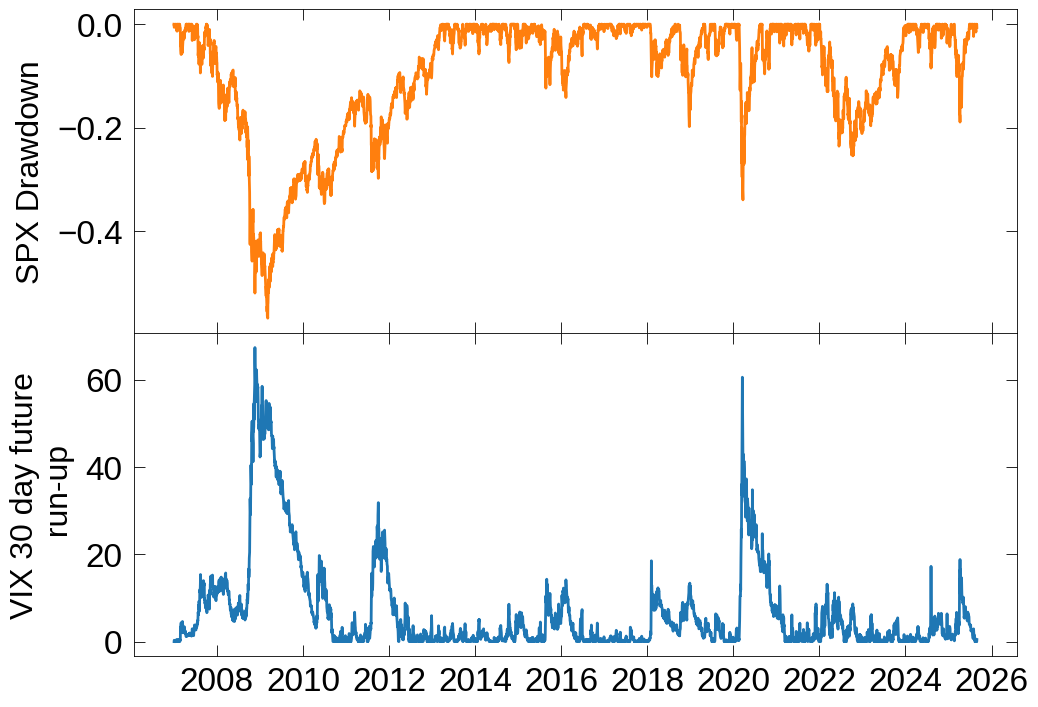

In [33]:
vix_30d['unit_contract_runup'] = vix_30d['unit_contract_cumpnl'] - vix_30d['unit_contract_cumpnl'].expanding().min()
spx['drawdown'] = spx['spx_close'] / spx['spx_close'].cummax() - 1.0

fig, ax = plt.subplots(2, 1, figsize=(9.2 * 1.5, 1.5 * 5.6), sharex=True)
# vix_30d['unit_contract_runup'].plot(ax=ax[1])
fig.subplots_adjust(hspace=0.)


ax[0].plot(spx['drawdown'], color='tab:orange')
ax[1].plot(vix_30d['unit_contract_runup'], color='tab:blue')

ax[0].set_ylabel('SPX Drawdown', fontsize=23)
ax[1].set_ylabel('VIX 30 day future\n run-up', fontsize=23)

# SPX drawdown response

<font size=5>

- Plotted above is the drawdown in the SPX index and the run-up of the 30-day VIX future strategy.

$$
\mathrm{(run-up)}_t = \mathrm{CumulativePnL}_t - \min_{s \leq t} \mathrm{CumulativePnL}_s
$$
- The run-up shows how much money the strategy makes when the VIX index rises and illustrates its profitability in tail events.

- In tail events, the 30-day VIX future has strong positive returns but it's not necessarily a beta hedge.
- Although by 2010 the SPX hadn't fully recovered, the VIX futures strategy had lost all of its profit from the 2008-2009 tail event.
- In weak bear markets like 2022, this strategy struggles to make money.  Although the SPX is in a prolonged drawdown, market volatility is not high.

# Conclusions 

<font size=5>

- The long term bleed in this strategy can be attributed to the roll down of the front month to the spot level.
- A VIX futures strategy provides long SPX volatility exposure that can be profitable in tail events; however, it does not behave as a vanilla beta hedge.
- Some interesting things to check out:
    - A 7-day, or a 14-day VIX future strategy using the weekly contracts.  Short dated contracts aren't as clean as monthly contracts in OptionsMetrics.
    - A gamma scalping strategy using VIX options and VIX futures.  However, this encodes a path dependency in the strategy from a restriking rule.

